In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from itertools import combinations

In [2]:
def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na - 1) * np.std(a, ddof=1)**2 + (nb - 1) * np.std(b, ddof=1)**2) / (na + nb - 2))
    if pooled_std == 0:
        return 0.0
    return (np.mean(a) - np.mean(b)) / pooled_std

def mean_diff(a, b):
    """Calculate mean differences between two groups."""

    return (np.mean(a) - np.mean(b))

def run_ttest(vals_a, vals_b):
    if len(vals_a) < 2 or len(vals_b) < 2:
        return np.nan, np.nan
    _, p_value = stats.ttest_ind(vals_a, vals_b, equal_var=False)
    effect_size = cohens_d(vals_a, vals_b)
    return p_value, effect_size

import numpy as np

def run_permutation_test(vals_a, vals_b, n_permutations=10000, random_state=None):
    vals_a = np.asarray(vals_a)
    vals_b = np.asarray(vals_b)

    if len(vals_a) < 2 or len(vals_b) < 2:
        return np.nan, np.nan

    observed_stat = np.mean(vals_a) - np.mean(vals_b)
    combined = np.concatenate([vals_a, vals_b])
    n_a = len(vals_a)

    rng = np.random.default_rng(random_state)

    perm_stats = np.empty(n_permutations)
    for i in range(n_permutations):
        permuted = rng.permutation(combined)
        perm_a = permuted[:n_a]
        perm_b = permuted[n_a:]
        perm_stats[i] = np.mean(perm_a) - np.mean(perm_b)

    p_value = (np.sum(np.abs(perm_stats) >= np.abs(observed_stat)) + 1) / (n_permutations + 1)
    # effect_size = cohens_d(vals_a, vals_b)
    effect_size = mean_diff(vals_a, vals_b)

    return p_value, effect_size

In [2]:
merged_df = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/all_metrics_1and2percent.csv')
merged_df = merged_df[['disease', 'setting', 'method', 'category',
                        'bio_sim_300', 'bio_sim_150',
                        'top_recall_150', 'succ_150',
                        'top_recall_300', 'succ_300',
                        'bedroc_150', 'bedroc_300', 'auroc']]

selected_metrics = ['bio_sim_300', 'bio_sim_150',
                    'top_recall_150', 'top_recall_300',
                    'bedroc_150', 'bedroc_300', 'auroc']

## OC

In [5]:
merged_df['setting'].unique(),merged_df['method'].unique()

(array(['df_gnn_occsvm_pred', '2019_occ_deep_svd_pred/pred.pkl',
        '2019_nn_all_pred', '2019_rf_renamed_pred', '2019_mf_add_pred',
        'graphsage', 'gcn'], dtype=object),
 array(['early_fused', 'early_fused_ppi', 'late_fused', 'late_fused_ppi',
        'ppi_emb_n2v', 'ppi_emb_dw', 'ppi_emb_df', 'literature_emb',
        'seq_emb_esm', 'seq_emb_port', 'mid_linear_fused', 'mid_geo_fused',
        'mid_linear_fused_ppi', 'mid_geo_fused_ppi', 'occ_svm',
        'uniport_ppi_2019', 'mid_fused', 'mid_fused_ppi'], dtype=object))

In [6]:
selected_pairs = [('df_gnn_occsvm_pred', 'occ_svm'),
    ('df_gnn_occsvm_pred', 'ppi_emb_n2v'),
    ('2019_nn_all_pred', 'ppi_emb_n2v'),
    ('2019_occ_deep_svd_pred/pred.pkl', 'uniport_ppi_2019')]
subresults = (merged_df.set_index(['setting', 'method']).loc[selected_pairs].reset_index())

method_map = {
    ('df_gnn_occsvm_pred', 'occ_svm'): 'occ-svm',
    ('df_gnn_occsvm_pred', 'ppi_emb_n2v'): 'bagging-svm',
    ('2019_nn_all_pred', 'ppi_emb_n2v'): 'bagging-dnn',
    ('2019_occ_deep_svd_pred/pred.pkl', 'uniport_ppi_2019'): 'occ-deepsvdd',
}

# (optional but recommended) normalize strings to avoid hidden whitespace issues
subresults['setting'] = subresults['setting'].astype(str).str.strip()
subresults['method']  = subresults['method'].astype(str).str.strip()

# build a MultiIndex key per row and map using the dict
keys = pd.MultiIndex.from_frame(subresults[['setting', 'method']])
new_method = keys.map(method_map)  # returns array with mapped values or NaN

# apply mapped names where available
subresults.loc[~pd.isna(new_method), 'method'] = new_method[~pd.isna(new_method)]

subresults = subresults.sort_values("category").reset_index(drop=True)



In [7]:
subresults

,setting,method,disease,category,bio_sim_300,bio_sim_150,top_recall_150,succ_150,top_recall_300,succ_300,bedroc_150,bedroc_300,auroc
0,2019_occ_deep_svd_pred/pred.pkl,occ-deepsvdd,ICD10_D83,Diseases of the blood and certain disorders(3),0.042570,0.034014,0.000000,0,0.000000,0,5.470495e-13,7.393357e-07,0.824491
1,2019_nn_all_pred,bagging-dnn,ICD10_D83,Diseases of the blood and certain disorders(3),0.094017,0.112853,0.000000,0,0.000000,0,6.611870e-22,1.818229e-11,0.603205
2,df_gnn_occsvm_pred,occ-svm,ICD10_D57,Diseases of the blood and certain disorders(3),0.017065,0.019904,0.000000,0,0.000000,0,1.769973e-09,4.207105e-05,0.874745
3,df_gnn_occsvm_pred,occ-svm,ICD10_D66,Diseases of the blood and certain disorders(3),0.043928,0.038727,0.000000,0,0.000000,0,4.717924e-04,2.172078e-02,0.952396
4,2019_nn_all_pred,bagging-dnn,ICD10_D66,Diseases of the blood and certain disorders(3),0.131336,0.129477,0.000000,0,0.000000,0,1.137555e-02,1.066562e-01,0.972178
...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,df_gnn_occsvm_pred,occ-svm,ICD10_C67,Neoplasms(8),0.246835,0.256968,0.421053,1,0.526316,1,3.679858e-01,4.244473e-01,0.778771
188,df_gnn_occsvm_pred,bagging-svm,ICD10_C53,Neoplasms(8),0.081548,0.099920,0.000000,0,0.000000,0,3.091125e-06,1.051259e-03,0.867611
189,2019_occ_deep_svd_pred/pred.pkl,occ-deepsvdd,ICD10_C67,Neoplasms(8),0.251302,0.243051,0.333333,1,0.458333,1,2.943262e-01,3.518420e-01,0.791002
190,2019_nn_all_pred,bagging-dnn,ICD10_C67,Neoplasms(8),0.276879,0.207087,0.157895,1,0.210526,1,9.487327e-02,1.471117e-01,0.702682


In [8]:
results = []

for pair in [['bagging-svm', 'occ-svm'], ['bagging-dnn', 'occ-deepsvdd']]:
    for metric in selected_metrics:
        vals_a = subresults[subresults['method'] == pair[0]][metric].dropna().values
        vals_b = subresults[subresults['method'] == pair[1]][metric].dropna().values

        p_value, effect_size = run_permutation_test(vals_a, vals_b)

        results.append({
            'setting': 'oc vs bagging',
            'metric': metric,
            'compared_groups': f'{pair[0]} vs {pair[1]}',
            'p_value': p_value,
            'observed_difference': effect_size
        })

results_oc = pd.DataFrame(results)

In [9]:
results_oc

,setting,metric,compared_groups,p_value,observed_difference
0,oc vs bagging,bio_sim_300,bagging-svm vs occ-svm,0.004700,0.056629
1,oc vs bagging,bio_sim_150,bagging-svm vs occ-svm,0.002100,0.062963
2,oc vs bagging,top_recall_150,bagging-svm vs occ-svm,0.064194,0.100023
3,oc vs bagging,top_recall_300,bagging-svm vs occ-svm,0.113289,0.117320
4,oc vs bagging,bedroc_150,bagging-svm vs occ-svm,0.048395,0.077942
5,oc vs bagging,bedroc_300,bagging-svm vs occ-svm,0.038596,0.098396
6,oc vs bagging,auroc,bagging-svm vs occ-svm,0.032097,0.086542
7,oc vs bagging,bio_sim_300,bagging-dnn vs occ-deepsvdd,0.017998,0.043757
8,oc vs bagging,bio_sim_150,bagging-dnn vs occ-deepsvdd,0.054895,0.033300
9,oc vs bagging,top_recall_150,bagging-dnn vs occ-deepsvdd,0.395260,-0.032446


## fusion

In [3]:
fusion_features = ['early_fused', 'late_fused','mid_linear_fused','mid_geo_fused','early_fused_ppi', 'late_fused_ppi', 'mid_linear_fused_ppi', 'mid_geo_fused_ppi', 'mid_fused','mid_fused_ppi']
fusion_df = merged_df[merged_df['method'].isin(fusion_features)]

In [4]:
fusion_df_mean_across_method = (
    fusion_df
    .groupby(['setting', 'category'], as_index=False)
    .mean(numeric_only=True)
)

In [6]:
fusion_df_mean_across_method['setting'].unique()

array(['2019_nn_all_pred', 'df_gnn_occsvm_pred'], dtype=object)

In [9]:
fusion_df_mean_across_method[fusion_df_mean_across_method['setting']=='df_gnn_occsvm_pred'].round(3)

,setting,category,bio_sim_300,bio_sim_150,top_recall_150,succ_150,top_recall_300,succ_300,bedroc_150,bedroc_300,auroc
11,df_gnn_occsvm_pred,Diseases of the blood and certain disorders(3),0.062,0.076,0.375,0.375,0.500,0.500,0.284,0.376,0.913
12,df_gnn_occsvm_pred,Diseases of the circulatory system(7),0.189,0.199,0.208,0.804,0.254,0.857,0.158,0.199,0.851
13,df_gnn_occsvm_pred,Diseases of the digestive system(2),0.245,0.269,0.031,0.125,0.203,0.500,0.028,0.085,0.827
14,df_gnn_occsvm_pred,Diseases of the genitourinary system(6),0.177,0.196,0.181,0.312,0.208,0.417,0.091,0.144,0.756
15,df_gnn_occsvm_pred,Diseases of the musculoskeletal system and con...,0.142,0.161,0.312,0.417,0.417,0.500,0.184,0.291,0.916
16,df_gnn_occsvm_pred,Diseases of the nervous system(7),0.120,0.126,0.109,0.161,0.192,0.321,0.060,0.109,0.737
17,df_gnn_occsvm_pred,Diseases of the respiratory system(3),0.157,0.163,0.333,0.333,0.611,0.667,0.221,0.353,0.958
18,df_gnn_occsvm_pred,Diseases of the skin and subcutaneous tissue(2),0.248,0.266,0.500,0.500,0.500,0.500,0.456,0.489,0.965
19,df_gnn_occsvm_pred,"Endocrine, nutritional and metabolic diseases(2)",0.297,0.265,0.277,0.500,0.339,0.500,0.188,0.246,0.757
20,df_gnn_occsvm_pred,Mental and behavioural disorders(5),0.133,0.114,0.034,0.250,0.056,0.400,0.018,0.034,0.669


In [10]:
fusion_df_mean_across_method[fusion_df_mean_across_method['setting']=='2019_nn_all_pred'].round(3)

,setting,category,bio_sim_300,bio_sim_150,top_recall_150,succ_150,top_recall_300,succ_300,bedroc_150,bedroc_300,auroc
0,2019_nn_all_pred,Diseases of the blood and certain disorders(3),0.071,0.083,0.222,0.222,0.556,0.556,0.120,0.252,0.819
1,2019_nn_all_pred,Diseases of the circulatory system(7),0.171,0.159,0.207,0.738,0.245,0.833,0.152,0.193,0.831
2,2019_nn_all_pred,Diseases of the digestive system(2),0.247,0.263,0.021,0.167,0.146,0.417,0.025,0.074,0.809
3,2019_nn_all_pred,Diseases of the genitourinary system(6),0.170,0.175,0.157,0.306,0.222,0.417,0.114,0.156,0.746
4,2019_nn_all_pred,Diseases of the musculoskeletal system and con...,0.144,0.156,0.167,0.222,0.194,0.278,0.108,0.174,0.899
5,2019_nn_all_pred,Diseases of the nervous system(7),0.108,0.088,0.167,0.262,0.244,0.381,0.088,0.142,0.735
6,2019_nn_all_pred,Diseases of the respiratory system(3),0.152,0.147,0.444,0.444,0.500,0.500,0.247,0.357,0.942
7,2019_nn_all_pred,Diseases of the skin and subcutaneous tissue(2),0.257,0.271,0.500,0.500,0.542,0.583,0.468,0.516,0.959
8,2019_nn_all_pred,"Endocrine, nutritional and metabolic diseases(2)",0.187,0.136,0.071,0.333,0.179,0.500,0.044,0.097,0.714
9,2019_nn_all_pred,Mental and behavioural disorders(5),0.056,0.040,0.039,0.333,0.053,0.400,0.022,0.036,0.604


In [11]:
fusion_df_mean = (
    fusion_df
    .groupby(['setting', 'method', 'category'], as_index=False)
    .mean(numeric_only=True)
)

In [14]:
fusion_df_mean.groupby('category', group_keys=False).apply(lambda df: df.nlargest(2, 'top_recall_150'))

/tmp/ipykernel_1694258/3166412521.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fusion_df_mean.groupby('category', group_keys=False).apply(lambda df: df.nlargest(2, 'top_recall_150'))


,setting,method,category,bio_sim_300,bio_sim_150,top_recall_150,succ_150,top_recall_300,succ_300,bedroc_150,bedroc_300,auroc
121,df_gnn_occsvm_pred,mid_geo_fused_ppi,Diseases of the blood and certain disorders(3),0.049982,0.058586,0.666667,0.666667,0.666667,0.666667,0.304791,0.436848,0.946116
11,2019_nn_all_pred,early_fused_ppi,Diseases of the blood and certain disorders(3),0.070280,0.091580,0.333333,0.333333,0.666667,0.666667,0.171603,0.328398,0.870620
45,2019_nn_all_pred,mid_fused,Diseases of the circulatory system(7),0.164323,0.165873,0.237118,0.857143,0.276679,0.857143,0.187090,0.228807,0.867789
56,2019_nn_all_pred,mid_fused_ppi,Diseases of the circulatory system(7),0.170732,0.166571,0.231624,0.857143,0.263346,0.857143,0.170518,0.218658,0.871285
90,df_gnn_occsvm_pred,late_fused,Diseases of the digestive system(2),0.260928,0.281237,0.125000,0.500000,0.187500,0.500000,0.055795,0.117669,0.847406
134,df_gnn_occsvm_pred,mid_linear_fused,Diseases of the digestive system(2),0.246857,0.278419,0.125000,0.500000,0.250000,0.500000,0.039909,0.100730,0.857970
47,2019_nn_all_pred,mid_fused,Diseases of the genitourinary system(6),0.174464,0.184825,0.277778,0.500000,0.277778,0.500000,0.171328,0.217290,0.752023
25,2019_nn_all_pred,late_fused,Diseases of the genitourinary system(6),0.164351,0.178272,0.194444,0.333333,0.194444,0.333333,0.129413,0.172081,0.740336
125,df_gnn_occsvm_pred,mid_geo_fused_ppi,Diseases of the musculoskeletal system and con...,0.119342,0.138255,0.666667,0.666667,0.666667,0.666667,0.305617,0.439528,0.944677
114,df_gnn_occsvm_pred,mid_geo_fused,Diseases of the musculoskeletal system and con...,0.147991,0.177852,0.500000,0.666667,0.500000,0.666667,0.286984,0.370947,0.936056


In [13]:
fusion_df_mean[
    fusion_df_mean['method'].str.contains('early')
].sort_values(
    by=['top_recall_150', 'top_recall_300', 'bedroc_150', 'bedroc_300'],
    ascending=False
)

,setting,method,category,bio_sim_300,bio_sim_150,top_recall_150,succ_150,top_recall_300,succ_300,bedroc_150,bedroc_300,auroc
17,2019_nn_all_pred,early_fused_ppi,Diseases of the respiratory system(3),0.156435,0.141529,0.666667,0.666667,0.666667,0.666667,0.416791,0.527390,0.951933
83,df_gnn_occsvm_pred,early_fused_ppi,Diseases of the respiratory system(3),0.150760,0.161893,0.666667,0.666667,0.666667,0.666667,0.326947,0.461309,0.970485
84,df_gnn_occsvm_pred,early_fused_ppi,Diseases of the skin and subcutaneous tissue(2),0.251057,0.282601,0.500000,0.500000,0.500000,0.500000,0.480384,0.502986,0.974428
18,2019_nn_all_pred,early_fused_ppi,Diseases of the skin and subcutaneous tissue(2),0.267916,0.272600,0.500000,0.500000,0.500000,0.500000,0.433875,0.486436,0.979585
7,2019_nn_all_pred,early_fused,Diseases of the skin and subcutaneous tissue(2),0.244119,0.237989,0.500000,0.500000,0.500000,0.500000,0.428454,0.462849,0.852239
73,df_gnn_occsvm_pred,early_fused,Diseases of the skin and subcutaneous tissue(2),0.247983,0.235253,0.500000,0.500000,0.500000,0.500000,0.394581,0.444176,0.916240
11,2019_nn_all_pred,early_fused_ppi,Diseases of the blood and certain disorders(3),0.070280,0.091580,0.333333,0.333333,0.666667,0.666667,0.171603,0.328398,0.870620
77,df_gnn_occsvm_pred,early_fused_ppi,Diseases of the blood and certain disorders(3),0.064998,0.085690,0.333333,0.333333,0.333333,0.333333,0.245717,0.333791,0.940221
66,df_gnn_occsvm_pred,early_fused,Diseases of the blood and certain disorders(3),0.073762,0.082035,0.333333,0.333333,0.333333,0.333333,0.185671,0.250282,0.790964
85,df_gnn_occsvm_pred,early_fused_ppi,"Endocrine, nutritional and metabolic diseases(2)",0.291750,0.277416,0.285714,0.500000,0.357143,0.500000,0.164998,0.235315,0.764180


In [9]:
fusion_df_mean['category'].unique()

array(['Diseases of the blood and certain disorders(3)',
       'Diseases of the circulatory system(7)',
       'Diseases of the digestive system(2)',
       'Diseases of the genitourinary system(6)',
       'Diseases of the musculoskeletal system and connective tissue(3)',
       'Diseases of the nervous system(7)',
       'Diseases of the respiratory system(3)',
       'Diseases of the skin and subcutaneous tissue(2)',
       'Endocrine, nutritional and metabolic diseases(2)',
       'Mental and behavioural disorders(5)', 'Neoplasms(8)'],
      dtype=object)

In [10]:
fusion_df_mean[fusion_df_mean['category'] == 'Diseases of the blood and certain disorders(3)'].round(3)

,setting,method,category,bio_sim_300,bio_sim_150,top_recall_150,succ_150,top_recall_300,succ_300,bedroc_150,bedroc_300,auroc
0,2019_nn_all_pred,early_fused,Diseases of the blood and certain disorders(3),0.078,0.081,0.000,0.000,0.000,0.000,0.001,0.015,0.625
11,2019_nn_all_pred,early_fused_ppi,Diseases of the blood and certain disorders(3),0.070,0.092,0.333,0.333,0.667,0.667,0.172,0.328,0.871
22,2019_nn_all_pred,late_fused,Diseases of the blood and certain disorders(3),0.072,0.083,0.000,0.000,0.667,0.667,0.052,0.186,0.861
33,2019_nn_all_pred,late_fused_ppi,Diseases of the blood and certain disorders(3),0.073,0.092,0.333,0.333,0.667,0.667,0.145,0.310,0.855
44,2019_nn_all_pred,mid_fused,Diseases of the blood and certain disorders(3),0.065,0.077,0.333,0.333,0.667,0.667,0.151,0.315,0.851
55,2019_nn_all_pred,mid_fused_ppi,Diseases of the blood and certain disorders(3),0.068,0.074,0.333,0.333,0.667,0.667,0.202,0.357,0.854
66,df_gnn_occsvm_pred,early_fused,Diseases of the blood and certain disorders(3),0.074,0.082,0.333,0.333,0.333,0.333,0.186,0.250,0.791
77,df_gnn_occsvm_pred,early_fused_ppi,Diseases of the blood and certain disorders(3),0.065,0.086,0.333,0.333,0.333,0.333,0.246,0.334,0.940
88,df_gnn_occsvm_pred,late_fused,Diseases of the blood and certain disorders(3),0.068,0.086,0.333,0.333,0.333,0.333,0.320,0.379,0.922
99,df_gnn_occsvm_pred,late_fused_ppi,Diseases of the blood and certain disorders(3),0.057,0.073,0.333,0.333,0.667,0.667,0.299,0.413,0.948


### no category

In [10]:
svm_features = ['early_fused', 'late_fused','mid_linear_fused','mid_geo_fused']
svm_ppi = ['early_fused_ppi', 'late_fused_ppi', 'mid_linear_fused_ppi', 'mid_geo_fused_ppi']
dnn_features = ['early_fused', 'late_fused', 'mid_fused']
dnn_ppi = ['early_fused_ppi', 'late_fused_ppi','mid_fused_ppi']

settings_dict = {'Kernel_fused':['df_gnn_occsvm_pred',svm_features],
            'Kernel_fused_ppi':['df_gnn_occsvm_pred',svm_ppi],
            'DNN_fused':['2019_nn_all_pred',dnn_features],
            'DNN_fused_ppi':['2019_nn_all_pred',dnn_ppi]}

for setting in list(settings_dict.keys()):
    for metric in selected_metrics:
        filtered_df = merged_df[(merged_df['setting']==settings_dict[setting][0])&(merged_df['method'].isin(settings_dict[setting][1]))]
        break
    break

In [11]:
filtered_df

,disease,setting,method,category,bio_sim_300,bio_sim_150,top_recall_150,succ_150,top_recall_300,succ_300,bedroc_150,bedroc_300,auroc
0,ICD10_C16,df_gnn_occsvm_pred,early_fused,Neoplasms(8),0.197614,0.220574,0.20,1,0.32,1,1.056337e-01,1.786213e-01,0.861021
2,ICD10_C16,df_gnn_occsvm_pred,late_fused,Neoplasms(8),0.179952,0.186959,0.16,1,0.32,1,1.279304e-01,2.138990e-01,0.886881
10,ICD10_C16,df_gnn_occsvm_pred,mid_linear_fused,Neoplasms(8),0.155381,0.172914,0.20,1,0.36,1,1.962768e-01,2.776490e-01,0.895194
11,ICD10_C16,df_gnn_occsvm_pred,mid_geo_fused,Neoplasms(8),0.163062,0.199242,0.08,1,0.16,1,7.314478e-02,1.431191e-01,0.888830
34,ICD10_F31,df_gnn_occsvm_pred,early_fused,Mental and behavioural disorders(5),0.304136,0.230836,0.00,0,0.00,0,1.833038e-33,4.281399e-17,0.531484
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1575,ICD10_K44,df_gnn_occsvm_pred,mid_geo_fused,Diseases of the digestive system(2),0.200726,0.237480,0.00,0,0.00,0,6.662824e-08,1.290845e-04,0.793501
1598,ICD10_G43,df_gnn_occsvm_pred,early_fused,Diseases of the nervous system(7),0.034221,0.043478,0.00,0,0.25,1,2.394231e-02,7.971000e-02,0.757438
1600,ICD10_G43,df_gnn_occsvm_pred,late_fused,Diseases of the nervous system(7),0.022201,0.039773,0.00,0,0.25,1,1.359704e-02,5.833523e-02,0.860850
1608,ICD10_G43,df_gnn_occsvm_pred,mid_linear_fused,Diseases of the nervous system(7),0.020374,0.033742,0.00,0,0.00,0,5.178619e-03,3.627345e-02,0.836334


In [12]:
svm_features = ['early_fused', 'late_fused','mid_linear_fused','mid_geo_fused']
svm_ppi = ['early_fused_ppi', 'late_fused_ppi', 'mid_linear_fused_ppi', 'mid_geo_fused_ppi']
dnn_features = ['early_fused', 'late_fused', 'mid_fused']
dnn_ppi = ['early_fused_ppi', 'late_fused_ppi','mid_fused_ppi']

settings_dict = {'Kernel_fused':['df_gnn_occsvm_pred',svm_features],
            'Kernel_fused_ppi':['df_gnn_occsvm_pred',svm_ppi],
            'DNN_fused':['2019_nn_all_pred',dnn_features],
            'DNN_fused_ppi':['2019_nn_all_pred',dnn_ppi]}
results = []
for setting in list(settings_dict.keys()):
    filtered_df = merged_df[(merged_df['setting']==settings_dict[setting][0])&(merged_df['method'].isin(settings_dict[setting][1]))]
    for metric in selected_metrics:
        mean_scores = (
            filtered_df
            .groupby('method')[metric]
            .mean()
            .dropna()
        )
        best_method = mean_scores.idxmax()

        others = [m for m in settings_dict[setting][1] if m != best_method]

        for m in others:
            
            vals_a = filtered_df[filtered_df['method'] == best_method][metric].dropna().values
            vals_b = filtered_df[filtered_df['method'] == m][metric].dropna().values

            p_value, effect_size = run_permutation_test(vals_a, vals_b)

            results.append({
                'setting': setting,
                'metric': metric,
                'compared_groups': f'{best_method} vs {m}',
                'p_value': p_value,
                'observed_difference': effect_size
            })

results_fusion = pd.DataFrame(results)


In [13]:
results_fusion

,setting,metric,compared_groups,p_value,observed_difference
0,Kernel_fused,bio_sim_300,late_fused vs early_fused,0.845515,0.004301
1,Kernel_fused,bio_sim_300,late_fused vs mid_linear_fused,0.698730,0.009339
2,Kernel_fused,bio_sim_300,late_fused vs mid_geo_fused,0.870213,0.004167
3,Kernel_fused,bio_sim_150,mid_geo_fused vs early_fused,0.414259,0.017004
4,Kernel_fused,bio_sim_150,mid_geo_fused vs late_fused,0.948605,0.001384
...,...,...,...,...,...
65,DNN_fused_ppi,bedroc_150,mid_fused_ppi vs late_fused_ppi,0.316768,0.043534
66,DNN_fused_ppi,bedroc_300,mid_fused_ppi vs early_fused_ppi,0.589441,0.028491
67,DNN_fused_ppi,bedroc_300,mid_fused_ppi vs late_fused_ppi,0.403760,0.042452
68,DNN_fused_ppi,auroc,early_fused_ppi vs late_fused_ppi,0.956704,0.001880


## categories

### features

In [7]:
def cohens_d(a, b):
    """Calculate Cohen's d effect size between two groups."""
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na - 1) * np.std(a, ddof=1)**2 + (nb - 1) * np.std(b, ddof=1)**2) / (na + nb - 2))
    if pooled_std == 0:
        return 0.0
    return (np.mean(a) - np.mean(b)) / pooled_std

def mean_diff(a, b):
    """Calculate mean differences between two groups."""

    return (np.mean(a) - np.mean(b))

def feature_compare(merged_df, c):
    c_df = merged_df[merged_df['category'] == c].copy()
    sample_size = int(c[-2])

    selected_features = ['ppi_emb_df', 'ppi_emb_dw', 'ppi_emb_n2v', 'literature_emb', 'seq_emb_esm', 'seq_emb_port']
    settings = ['df_gnn_occsvm_pred', '2019_nn_all_pred', '2019_rf_renamed_pred', '2019_mf_add_pred', 'graphsage', 'gcn']

    map_name = {
        'df_gnn_occsvm_pred': 'SVM_features',
        '2019_nn_all_pred':   'DNN_features',
        '2019_rf_renamed_pred': 'RF_features',
        '2019_mf_add_pred':   'MF_features',
        'graphsage':          'GraphSAGE_features',
        'gcn':                'GCN_features'
    }

    ppi_features = [f for f in selected_features if f.startswith('ppi_')]
    lit_features = [f for f in selected_features if f.startswith('literature_')]
    seq_features = [f for f in selected_features if f.startswith('seq_')]

    # Each pair is (feature_a, feature_b), one from each group
    comparison_pairs = (
        [(p, l) for p in ppi_features for l in lit_features] +  # ppi vs literature
        [(p, s) for p in ppi_features for s in seq_features] +  # ppi vs seq
        [(l, s) for l in lit_features for s in seq_features]    # literature vs seq
    )

    results = []

    filtered_df = c_df[(c_df['method'].isin(selected_features))]

    for metric in selected_metrics:
        for feat_a, feat_b in comparison_pairs:
            vals_a = filtered_df[filtered_df['method'] == feat_a][metric].dropna().values
            vals_b = filtered_df[filtered_df['method'] == feat_b][metric].dropna().values
            p_value, effect_size = run_permutation_test(vals_a, vals_b)

            results.append({
                'category':        c,
                'sample_size':     sample_size,
                'setting':         'across_models',
                'metric':          metric,
                'compared_groups': f'{feat_a} vs {feat_b}',
                'p_value':         p_value,
                'effect_size':     effect_size
            })

    return pd.DataFrame(results, columns=['category', 'sample_size', 'setting', 'metric',
                                            'compared_groups', 'p_value', 'effect_size'])
    # for setting in settings:
    #     filtered_df = c_df[(c_df['setting'] == setting) & (c_df['method'].isin(selected_features))]

    #     if filtered_df.empty:
    #         continue

    #     for metric in selected_metrics:
    #         for feat_a, feat_b in comparison_pairs:
    #             vals_a = filtered_df[filtered_df['method'] == feat_a][metric].dropna().values
    #             vals_b = filtered_df[filtered_df['method'] == feat_b][metric].dropna().values
    #             p_value, effect_size = run_permutation_test(vals_a, vals_b)

    #             results.append({
    #                 'category':        c,
    #                 'sample_size':     sample_size,
    #                 'setting':         map_name.get(setting, setting),
    #                 'metric':          metric,
    #                 'compared_groups': f'{feat_a} vs {feat_b}',
    #                 'p_value':         p_value,
    #                 'effect_size':     effect_size
    #             })

    # return pd.DataFrame(results, columns=['category', 'sample_size', 'setting', 'metric',
    #                                       'compared_groups', 'p_value', 'effect_size'])


# ── Main ──────────────────────────────────────────────────────────────────────
merged_df = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/all_metrics_1and2percent.csv')
merged_df = merged_df[['disease', 'setting', 'method', 'category',
                        'bio_sim_300', 'bio_sim_150',
                        'top_recall_150', 'succ_150',
                        'top_recall_300', 'succ_300',
                        'bedroc_150', 'bedroc_300', 'auroc']]

selected_metrics = ['bio_sim_300', 'bio_sim_150',
                    'top_recall_150', 'top_recall_300',
                    'bedroc_150', 'bedroc_300', 'auroc']

all_results = pd.concat(
    [feature_compare(merged_df, c) for c in merged_df['category'].unique()],
    ignore_index=True
)

In [8]:
all_results.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_features_across_models_category.csv',index=False)

In [5]:
all_results = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_features_category.csv')

In [12]:
all_results

,category,sample_size,setting,metric,compared_groups,p_value,effect_size
0,Neoplasms(8),8,across_models,bio_sim_300,ppi_emb_df vs literature_emb,0.007599,-0.037437
1,Neoplasms(8),8,across_models,bio_sim_300,ppi_emb_dw vs literature_emb,0.090291,-0.025350
2,Neoplasms(8),8,across_models,bio_sim_300,ppi_emb_n2v vs literature_emb,0.122688,-0.022925
3,Neoplasms(8),8,across_models,bio_sim_300,ppi_emb_df vs seq_emb_esm,0.292471,-0.013293
4,Neoplasms(8),8,across_models,bio_sim_300,ppi_emb_df vs seq_emb_port,0.431857,-0.009510
...,...,...,...,...,...,...,...
842,Diseases of the skin and subcutaneous tissue(2),2,across_models,auroc,ppi_emb_dw vs seq_emb_port,0.029697,0.161761
843,Diseases of the skin and subcutaneous tissue(2),2,across_models,auroc,ppi_emb_n2v vs seq_emb_esm,0.032397,0.171742
844,Diseases of the skin and subcutaneous tissue(2),2,across_models,auroc,ppi_emb_n2v vs seq_emb_port,0.026997,0.166850
845,Diseases of the skin and subcutaneous tissue(2),2,across_models,auroc,literature_emb vs seq_emb_esm,0.049995,0.156806


In [9]:
target_metrics = ['top_recall_150', 'top_recall_300', 'bedroc_150', 'bedroc_300']

In [4]:
all_results['metric'].unique()

array(['bio_sim_300', 'bio_sim_150', 'top_recall_150', 'top_recall_300',
       'bedroc_150', 'bedroc_300', 'auroc'], dtype=object)

In [5]:
import matplotlib.pyplot as plt

(array([   7.,    0.,   53.,  139., 3189., 1276.,  330.,   32.,   17.,
          39.]),
 array([-0.66666667, -0.52222222, -0.37777778, -0.23333333, -0.08888889,
         0.05555556,  0.2       ,  0.34444444,  0.48888889,  0.63333333,
         0.77777778]),
 <BarContainer object of 10 artists>)

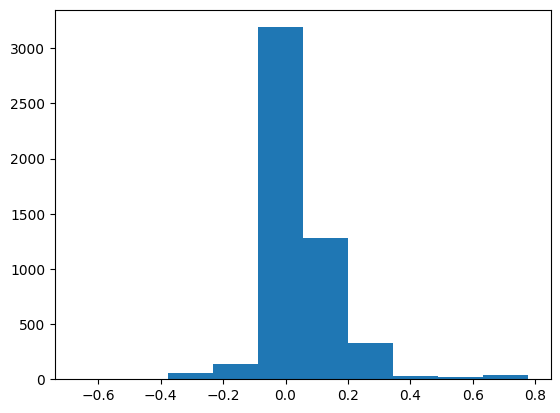

In [6]:
plt.hist(all_results['effect_size'])

### sub analysis for feature-model combination

In [ ]:
def summarize_conditions(high_effect_summary, c, target_metrics):
    target_set = set(target_metrics)
    
    def has_early(x):
        return len(set(x) & target_set) >= 2
    
    def has_bio(x):
        return any('bio' in m for m in x)
    
    def make_emb(df):
        df = df.copy()
        df['compared_groups_emb'] = (
            df['compared_groups']
            .str.split('vs')
            .apply(lambda x: '-'.join([item.strip()[:3] for item in x]))
        )
        return df['compared_groups_emb'].value_counts()
    
    # Base filter (category)
    base = high_effect_summary[high_effect_summary['category'] == c]
    
    # 1. high early discovery, no biosim
    cond1 = base[
        base['metric_lists'].apply(has_early) &
        base['metric_lists'].apply(lambda x: not has_bio(x))
    ]
    
    # 2. high early discovery, with biosim
    cond2 = base[
        base['metric_lists'].apply(has_early) &
        base['metric_lists'].apply(has_bio)
    ]
    
    # 3. no early discovery, but biosim
    cond3 = base[
        base['metric_lists'].apply(lambda x: not has_early(x)) &
        base['metric_lists'].apply(has_bio)
    ]
    
    return {
        'high_early_no_bio': make_emb(cond1),
        'high_early_with_bio': make_emb(cond2),
        'low_early_with_bio': make_emb(cond3),
    }

In [ ]:
positive_effect = dict()
high_effect = all_results[(all_results['effect_size']>=0.5)].copy()
high_effect_summary = high_effect[['category', 'setting', 'metric', 'compared_groups']]
high_effect_summary = (
    high_effect_summary.groupby(['category', 'setting', 'compared_groups'])['metric']
      .apply(list)
      .reset_index(name='metric_lists')
)
for c in high_effect_summary['category'].unique():
    positive_effect[c] = summarize_conditions(high_effect_summary, c, target_metrics)

In [ ]:
rows = []

for disease, sub_dict in positive_effect.items():
    for category, series in sub_dict.items():
        if series is None or len(series) == 0:
            continue  # skip empty Series
        
        for method, count in series.items():
            rows.append({
                "category": disease,
                "condition": category,
                "method": method,
                "count": count
            })

positive_effect_df = pd.DataFrame(rows)

denominator_map = {
    "ppi-seq": 36,
    "ppi-lit": 18,
    "lit-seq": 12
}

positive_effect_df["normalized_count"] = (
    positive_effect_df["count"] /
    positive_effect_df["method"].map(denominator_map)
)

In [ ]:
positive_effect_df[(positive_effect_df['normalized_count'] > 0.3)&(positive_effect_df['condition'] == 'high_early_with_bio')].sort_values(by=['category', 'method'])

In [ ]:
positive_effect_df[(positive_effect_df['normalized_count'] > 0.3)&(positive_effect_df['condition'] == 'high_early_no_bio')].sort_values(by=['category', 'method'])

In [ ]:
positive_effect_df[(positive_effect_df['normalized_count'] > 0.3)&(positive_effect_df['condition'] == 'low_early_with_bio')].sort_values(by=['category', 'method'])

In [ ]:
negative_effect = dict()
high_effect = all_results[(all_results['effect_size']<=-0.5)].copy()
high_effect_summary = high_effect[['category', 'setting', 'metric', 'compared_groups']]
high_effect_summary = (
    high_effect_summary.groupby(['category', 'setting', 'compared_groups'])['metric']
      .apply(list)
      .reset_index(name='metric_lists')
)
for c in high_effect_summary['category'].unique():
    negative_effect[c] = summarize_conditions(high_effect_summary, c, target_metrics)

In [ ]:
rows = []

for disease, sub_dict in negative_effect.items():
    for category, series in sub_dict.items():
        if series is None or len(series) == 0:
            continue  # skip empty Series
        
        for method, count in series.items():
            rows.append({
                "category": disease,
                "condition": category,
                "method": method,
                "count": count
            })

negative_effect_df = pd.DataFrame(rows)

denominator_map = {
    "ppi-seq": 36,
    "ppi-lit": 18,
    "lit-seq": 12
}

negative_effect_df["normalized_count"] = (
    negative_effect_df["count"] /
    negative_effect_df["method"].map(denominator_map)
)

negative_effect_df['method'] = (
    negative_effect_df['method']
    .str.split('-', expand=True)
    .apply(lambda x: x[1] + '-' + x[0], axis=1)
)

# negative_effect_df[negative_effect_df['normalized_count']>0.3]

In [ ]:
negative_effect_df[(negative_effect_df['normalized_count'] > 0.3)&(negative_effect_df['condition'] == 'high_early_with_bio')].sort_values(by=['category', 'method'])

In [ ]:
negative_effect_df[(negative_effect_df['normalized_count'] > 0.3)&(negative_effect_df['condition'] == 'high_early_no_bio')].sort_values(by=['category', 'method'])

In [ ]:
negative_effect_df[(negative_effect_df['normalized_count'] > 0.3)&(negative_effect_df['condition'] == 'low_early_with_bio')].sort_values(by=['category', 'method'])

### model compara

In [13]:
def model_compare(merged_df, c):
    c_df = merged_df[merged_df['category'] == c].copy()
    sample_size = int(c[-2])

    selected_features = ['ppi_emb_df', 'ppi_emb_dw', 'ppi_emb_n2v', 'literature_emb', 'seq_emb_esm', 'seq_emb_port']

    results = []

    method_mapping = {
        'df_gnn_occsvm_pred':   'SVM',
        'graphsage':            'GraphSAGE',
        'gcn':                  'GCN',
        '2019_nn_all_pred':     'DNN',
        '2019_rf_renamed_pred': 'RF',
        '2019_mf_add_pred':     'MF',
    }
    
    subresults = c_df[c_df['method'].isin(selected_features)]
    subresults['model'] = subresults['setting'].map(method_mapping)

    models = subresults['model'].unique()  # ['SVM', 'GraphSAGE', 'GCN', 'DNN', 'RF', 'MF']

    for metric in selected_metrics:
        for model_a, model_b in combinations(models, 2):
            vals_a = subresults[subresults['model'] == model_a][metric].dropna().values
            vals_b = subresults[subresults['model'] == model_b][metric].dropna().values
            p_value, effect_size = run_permutation_test(vals_a, vals_b)


            results.append({
                'category':        c,
                'sample_size':     sample_size,
                'feature':         'across_features',
                'metric':          metric,
                'compared_groups': f'{model_a} vs {model_b}',
                'p_value':         p_value,
                'effect_size':     effect_size
            })

    # for feature_i in selected_features:
    #     selected_pairs = [
    #         ('df_gnn_occsvm_pred',    feature_i),
    #         ('graphsage',             feature_i),
    #         ('gcn',                   feature_i),
    #         ('2019_nn_all_pred',      feature_i),
    #         ('2019_rf_renamed_pred',  feature_i),
    #         ('2019_mf_add_pred',      feature_i),
    #     ]
    #     method_mapping = dict(zip(selected_pairs, ['SVM', 'GraphSAGE', 'GCN', 'DNN', 'RF', 'MF']))

    #     subresults = c_df.set_index(['setting', 'method']).loc[selected_pairs].reset_index()
    #     subresults['model'] = [method_mapping[(row['setting'], row['method'])]
    #                            for _, row in subresults.iterrows()]

    #     models = subresults['model'].unique()  # ['SVM', 'GraphSAGE', 'GCN', 'DNN', 'RF', 'MF']

    #     for metric in selected_metrics:
    #         for model_a, model_b in combinations(models, 2):
    #             vals_a = subresults[subresults['model'] == model_a][metric].dropna().values
    #             vals_b = subresults[subresults['model'] == model_b][metric].dropna().values
    #             p_value, effect_size = run_permutation_test(vals_a, vals_b)


    #             results.append({
    #                 'category':        c,
    #                 'sample_size':     sample_size,
    #                 'feature':         feature_i,
    #                 'metric':          metric,
    #                 'compared_groups': f'{model_a} vs {model_b}',
    #                 'p_value':         p_value,
    #                 'effect_size':     effect_size
    #             })

    return pd.DataFrame(results, columns=['category', 'sample_size', 'feature', 'metric',
                                          'compared_groups', 'p_value', 'effect_size'])


# ── Main ──────────────────────────────────────────────────────────────────────
from itertools import combinations

all_results2 = pd.concat(
    [model_compare(merged_df, c) for c in merged_df['category'].unique()],
    ignore_index=True
)

/tmp/ipykernel_624892/1828381743.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subresults['model'] = subresults['setting'].map(method_mapping)
/tmp/ipykernel_624892/1828381743.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subresults['model'] = subresults['setting'].map(method_mapping)
/tmp/ipykernel_624892/1828381743.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the 

In [14]:
all_results2.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_models_across_features_category.csv',index=False)

In [15]:
all_results2

,category,sample_size,feature,metric,compared_groups,p_value,effect_size
0,Neoplasms(8),8,across_features,bio_sim_300,SVM vs DNN,0.633537,0.006834
1,Neoplasms(8),8,across_features,bio_sim_300,SVM vs RF,0.411459,0.011420
2,Neoplasms(8),8,across_features,bio_sim_300,SVM vs MF,0.000500,0.045655
3,Neoplasms(8),8,across_features,bio_sim_300,SVM vs GraphSAGE,0.744826,-0.004422
4,Neoplasms(8),8,across_features,bio_sim_300,SVM vs GCN,0.000400,0.050500
...,...,...,...,...,...,...,...
1150,Diseases of the skin and subcutaneous tissue(2),2,across_features,auroc,RF vs GraphSAGE,0.709729,-0.024982
1151,Diseases of the skin and subcutaneous tissue(2),2,across_features,auroc,RF vs GCN,0.397960,-0.068433
1152,Diseases of the skin and subcutaneous tissue(2),2,across_features,auroc,MF vs GraphSAGE,0.848715,-0.009145
1153,Diseases of the skin and subcutaneous tissue(2),2,across_features,auroc,MF vs GCN,0.215078,-0.052596


In [ ]:
# all_results2[(all_results2['effect_size']>=0.5)&(all_results2['category']=='Neoplasms(8)')]
high_effect = all_results2[(all_results2['effect_size']>=-0.5)].copy()
high_effect_summary = high_effect[['category', 'feature', 'metric', 'compared_groups']]
high_effect_summary = (
    high_effect_summary.groupby(['category', 'feature', 'compared_groups'])['metric']
      .apply(list)
      .reset_index(name='metric_lists')
)
high_effect_summary[high_effect_summary['category']=='Neoplasms(8)']

## save all

In [30]:
selected_features = ['ppi_emb_df', 'ppi_emb_dw', 'ppi_emb_n2v', 'literature_emb', 'seq_emb_esm', 'seq_emb_port']

map_name = {
    'df_gnn_occsvm_pred': 'SVM',
    '2019_nn_all_pred':   'DNN',
    '2019_rf_renamed_pred': 'RF',
    '2019_mf_add_pred':   'MF',
    'graphsage':          'GraphSAGE',
    'gcn':                'GCN'
}

selected_metrics = ['bio_sim_300', 'bio_sim_150',
                    'succ_150','succ_300',
                    'top_recall_150', 'top_recall_300',
                    'bedroc_150', 'bedroc_300', 'auroc']

mean_df = merged_df[merged_df['method'].isin(selected_features)].copy()
mean_df['model'] = mean_df['setting'].map(map_name)


In [31]:
# --- method-level mean ---
method_df = (
    mean_df
    .groupby(['category', 'method'])[selected_metrics]
    .mean()
    .reset_index()
)

# --- model-level mean ---
model_df = (
    mean_df
    .groupby(['category', 'model'])[selected_metrics]
    .mean()
    .reset_index()
)

# final outputs
method_df = method_df[['category', 'method'] + selected_metrics]
model_df = model_df[['category', 'model'] + selected_metrics]

In [39]:
mean_df['category'].unique()

array(['Neoplasms(8)', 'Mental and behavioural disorders(5)',
       'Diseases of the circulatory system(7)',
       'Diseases of the respiratory system(3)',
       'Diseases of the nervous system(7)',
       'Endocrine, nutritional and metabolic diseases(2)',
       'Diseases of the musculoskeletal system and connective tissue(3)',
       'Diseases of the blood and certain disorders(3)',
       'Diseases of the genitourinary system(6)',
       'Diseases of the digestive system(2)',
       'Diseases of the skin and subcutaneous tissue(2)'], dtype=object)

In [56]:
# d = 'Diseases of the respiratory system(3)'
# d = 'Diseases of the skin and subcutaneous tissue(2)'
# d = 'Diseases of the circulatory system(7)'
# d = 'Neoplasms(8)'
# d = 'Mental and behavioural disorders(5)'
# d = 'Diseases of the nervous system(7)'
d = 'Diseases of the digestive system(2)'

In [57]:
method_df[method_df['category']==d].round(3)

,category,method,bio_sim_300,bio_sim_150,succ_150,succ_300,top_recall_150,top_recall_300,bedroc_150,bedroc_300,auroc
12,Diseases of the digestive system(2),literature_emb,0.257,0.252,0.167,0.417,0.031,0.073,0.016,0.047,0.751
13,Diseases of the digestive system(2),ppi_emb_df,0.217,0.245,0.500,0.500,0.125,0.240,0.082,0.140,0.833
14,Diseases of the digestive system(2),ppi_emb_dw,0.231,0.253,0.250,0.500,0.031,0.156,0.030,0.081,0.813
15,Diseases of the digestive system(2),ppi_emb_n2v,0.222,0.253,0.333,0.500,0.052,0.198,0.043,0.106,0.797
16,Diseases of the digestive system(2),seq_emb_esm,0.213,0.187,0.417,0.500,0.094,0.188,0.059,0.102,0.783
17,Diseases of the digestive system(2),seq_emb_port,0.214,0.200,0.417,0.417,0.135,0.177,0.079,0.125,0.811


In [58]:
model_df[model_df['category']==d].round(3)

,category,model,bio_sim_300,bio_sim_150,succ_150,succ_300,top_recall_150,top_recall_300,bedroc_150,bedroc_300,auroc
12,Diseases of the digestive system(2),DNN,0.235,0.220,0.083,0.250,0.010,0.062,0.010,0.036,0.744
13,Diseases of the digestive system(2),GCN,0.203,0.229,0.500,0.500,0.104,0.271,0.075,0.145,0.861
14,Diseases of the digestive system(2),GraphSAGE,0.251,0.250,0.417,0.500,0.115,0.156,0.057,0.099,0.796
15,Diseases of the digestive system(2),MF,0.192,0.213,0.417,0.583,0.125,0.229,0.098,0.154,0.828
16,Diseases of the digestive system(2),RF,0.231,0.227,0.417,0.500,0.073,0.156,0.040,0.091,0.770
17,Diseases of the digestive system(2),SVM,0.241,0.250,0.250,0.500,0.042,0.156,0.030,0.076,0.789


In [59]:
method_df.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/mean_features_category.csv',index=False)
model_df.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/mean_models_category.csv',index=False)

## to do: check correction for description, provide p-value evidence

In [ ]:
# all_results2.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_models_category.csv',index=False)

# all_results.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_features_category.csv',index=False)

# feature_results.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_features.csv',index=False)
# model_results.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_models.csv',index=False)

# all_results2.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_models_category.csv',index=False)

# all_results.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_features_category.csv',index=False)

# feature_results.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_features.csv',index=False)
# model_results.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_models.csv',index=False)

# all_results.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_features_across_models_category.csv',index=False)
# all_results2.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_models_across_features_category.csv',index=False)
# method_df.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/mean_features_category.csv',index=False)
# model_df.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/mean_models_category.csv',index=False)
# feature_results.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_features(across).csv',index=False)
# model_results.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_models(across).csv',index=False)

In [64]:
import pandas as pd
from pathlib import Path

# Input CSV files
csv_files = [
    '/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_features(across).csv',
    '/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_models(across).csv',
    '/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_features_across_models_category.csv',
    '/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_models_across_features_category.csv',
    '/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/mean_features_category.csv',
    '/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/mean_models_category.csv'
]

# Output Excel file
output_excel = "/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_results_summary.xlsx"

# Description sheet content
description_lines = [
    "File Description",
    "",
    "1. P-values are calculated using a permutation test.",
    "2. Effect size is calculated using difference of means.",
    "3. Files with '_category' in the name are calculated using category groups.",
    "4. Files without '_category' are calculated by treating all samples as the same level.",
]

# Write to Excel
with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    # First sheet: description
    description_df = pd.DataFrame({"Description": description_lines})
    description_df.to_excel(writer, sheet_name="file_description", index=False)

    # Other sheets: one per CSV file, using CSV filename as sheet name
    for csv_path in csv_files:
        csv_path = Path(csv_path)
        sheet_name = csv_path.stem[:31]  # Excel sheet names max length = 31
        df = pd.read_csv(csv_path)
        df.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"Excel file saved to: {output_excel}")

Excel file saved to: /itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_mean_results_summary.xlsx


In [ ]:
# import pandas as pd
# from pathlib import Path

# # Input CSV files
# csv_files = [
#     "/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_models_category.csv",
#     "/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_features_category.csv",
#     "/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_features.csv",
#     "/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_models.csv",
# ]

# # Output Excel file
# output_excel = "/itf-fi-ml/shared/users/ziyuzh/svm/results/statistic/permutation_results_summary.xlsx"

# # Description sheet content
# description_lines = [
#     "File Description",
#     "",
#     "1. P-values are calculated using a permutation test.",
#     "2. Effect size is calculated using Cohen's d.",
#     "3. Files with '_category' in the name are calculated using category groups.",
#     "4. Files without '_category' are calculated by treating all samples as the same level.",
# ]

# # Write to Excel
# with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
#     # First sheet: description
#     description_df = pd.DataFrame({"Description": description_lines})
#     description_df.to_excel(writer, sheet_name="file_description", index=False)

#     # Other sheets: one per CSV file, using CSV filename as sheet name
#     for csv_path in csv_files:
#         csv_path = Path(csv_path)
#         sheet_name = csv_path.stem[:31]  # Excel sheet names max length = 31
#         df = pd.read_csv(csv_path)
#         df.to_excel(writer, sheet_name=sheet_name, index=False)

# print(f"Excel file saved to: {output_excel}")